# **Customer  Demographics Profiling:**

## 1. **Age Distribution Analysis:**

In [52]:
import pandas as pd 
import numpy as np 
import sklearn as slr 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [53]:
data= pd.read_csv("train.csv", sep= ";")
data.shape

(45211, 17)

In [54]:
data.head(3)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no


In [55]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [56]:
data["subscribed"]= data["y"]

In [57]:
data.drop(["y"], inplace= True, axis= 1)

In [58]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'subscribed'],
      dtype='object')

In [59]:
data["age"].describe().reset_index()

,index,age
0,count,45211.000000
1,mean,40.936210
2,std,10.618762
3,min,18.000000
4,25%,33.000000
5,50%,39.000000
6,75%,48.000000
7,max,95.000000


- Average age of individuals is approximately 40.94 years.

- **Standard Deviation $(std)$**: The spread of ages around the mean is about 10.62 years.

- Youngest individual in the dataset is 18 years old.

- **25% (1st Quartile)**: 25% of individuals are aged 33 or younger.

- **50% $(Median)$**: Half of the individuals are aged 39 or younger.

- **75% (3rd Quartile)**: 75% of individuals are aged 48 or younger.

- Oldest individual in the dataset is 95 years old.

<Axes: ylabel='age'>

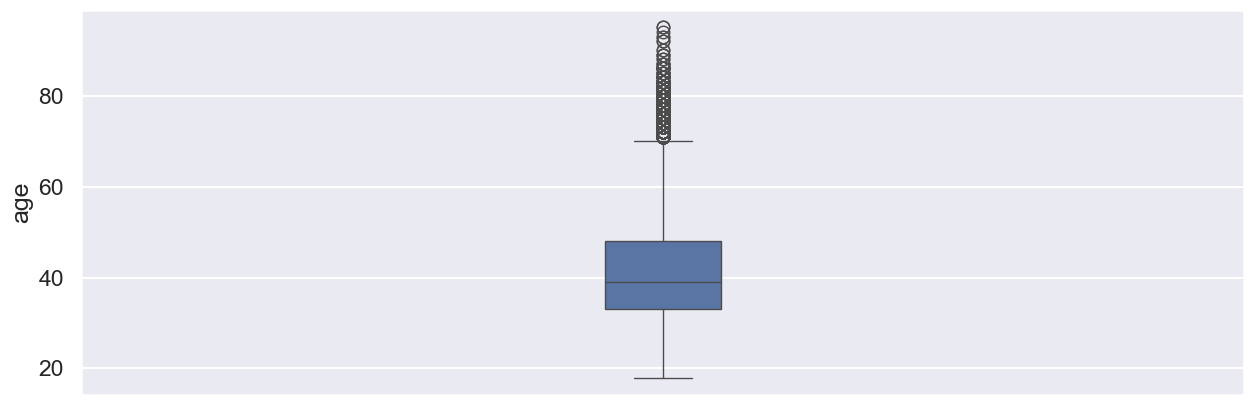

In [60]:
plt.figure(figsize=(15, 5))
sns.set_theme(context="talk", style="darkgrid", palette="deep")
sns.boxplot(data= data["age"], width= 0.1)

<Figure size 1500x500 with 0 Axes>

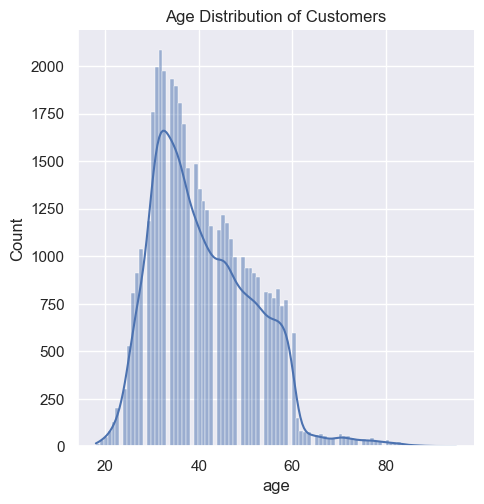

In [61]:
plt.figure(figsize=(15, 5))
sns.set_theme(context="notebook", style="darkgrid", palette="deep")
sns.displot(data= data, x= "age", kde= True)
plt.title("Age Distribution of Customers")
plt.show()

<Axes: xlabel='age', ylabel='Density'>

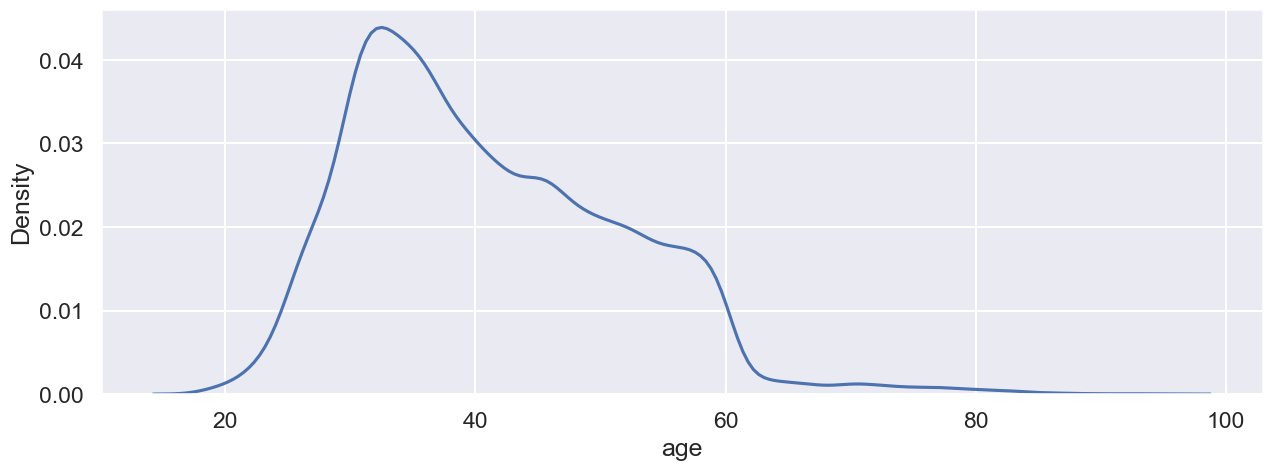

In [62]:
plt.figure(figsize=(15, 5))
sns.set_theme(context="talk", style="darkgrid", palette="deep")
sns.kdeplot(data= data, x= "age")

In [63]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'subscribed'],
      dtype='object')

**Considering Raw Counts:** *(May be Misleading sometime)*

In [64]:
axs= data.groupby(by= "age")["subscribed"].value_counts(normalize= False).reset_index()

In [65]:
# now, perform binning for age accourding to quantiles: 
axs["age_bin"]= pd.qcut(axs["age"], q= 4, labels= ["young", "middle", "old", "senior"])

In [66]:
axs.shape

(148, 4)

In [67]:
axs.head()

,age,subscribed,count,age_bin
0,18,yes,7,young
1,18,no,5,young
2,19,no,24,young
3,19,yes,11,young
4,20,no,35,young


<Axes: xlabel='age_bin', ylabel='count'>

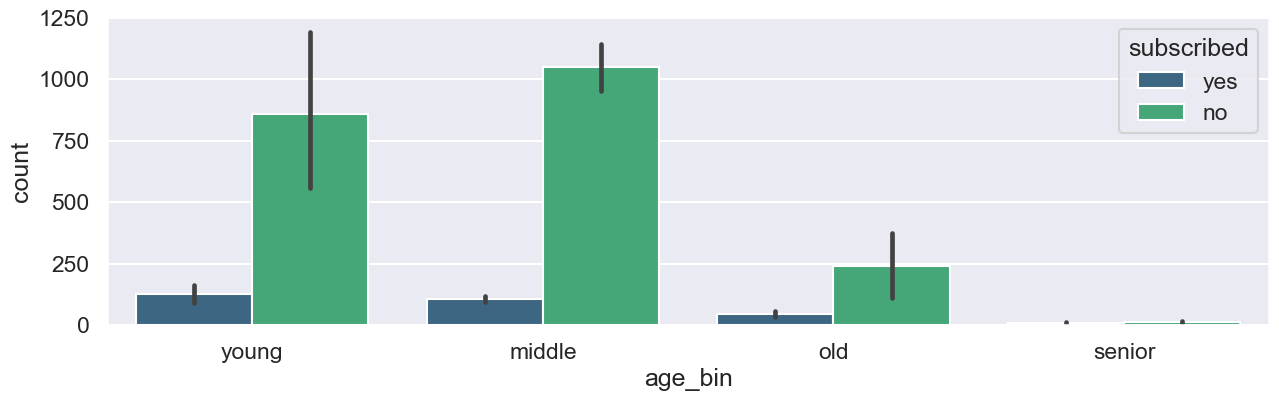

In [68]:
plt.figure(figsize= (15, 4))
sns.barplot(data= axs, x= "age_bin", y= "count", hue= "subscribed", palette= "viridis")

**Considering the proportion instead of raw counts:**

In [69]:
axs= data.groupby(by= "age")["subscribed"].value_counts(normalize= True).reset_index()

In [70]:
# now, perform binning for age accourding to quantiles: 
axs["age_bin"]= pd.qcut(axs["age"], q= 4, labels= ["young", "middle", "old", "senior"])

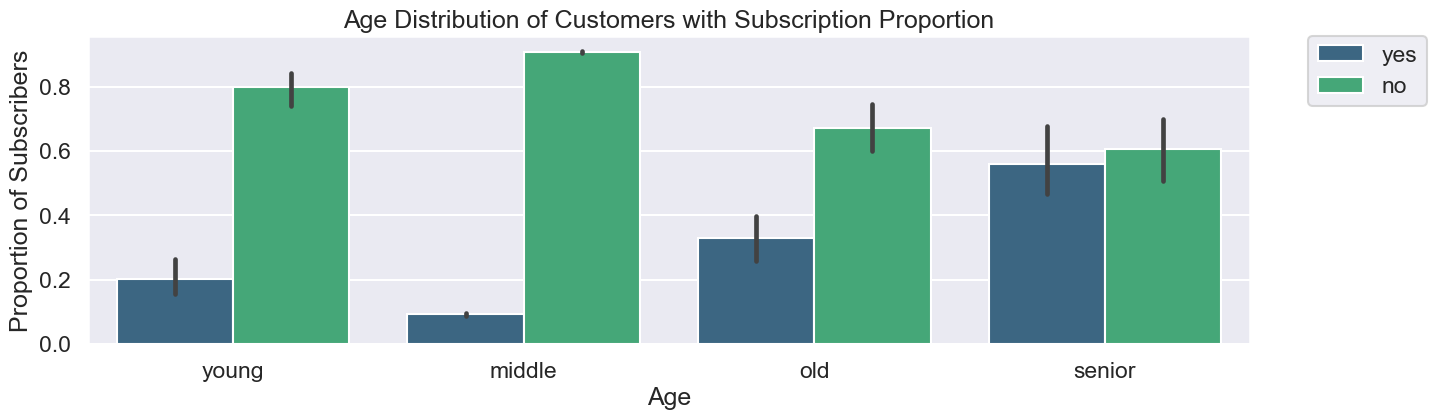

In [73]:
plt.figure(figsize= (15, 4))
sns.barplot(data= axs, x= "age_bin", y= "proportion", hue= "subscribed", palette= "viridis")
# plot legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title("Age Distribution of Customers with Subscription Proportion")
plt.xlabel("Age")
plt.ylabel("Proportion of Subscribers")
plt.show()

* **`Young`** and **`middle-aged`** customers have a significantly higher proportion of non-subscribers.

* **`Old`** customers show a more balanced distribution, though more still did not subscribe.

* **`Senior`** customers have nearly equal proportions of subscribers and non-subscribers, with slightly more non-subscribers.

* So, the subscription rates increase with age, peaking among seniors.